In [55]:
# Importing the libraries
import pandas as pd
import numpy as np
from random import random
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.stats.stattools as sm_tools
import statsmodels.stats.diagnostic as sm_diagnostic
from statsmodels.compat import lzip

In [56]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({'figure.figsize':(10,8), 'figure.dpi':50})

In [57]:
# Setting the random seed
np.random.seed(123)

### Autocorrelation

In [58]:
# Generating the dataset
N = 200
beta_vec = np.array([10, 5, -3])
rho = 0.8

x1 = np.linspace(start=0, stop=5, num=N)
x2 = np.random.choice(np.linspace(
    start=3, stop=17, num=80), size=N, replace=True)
# serially correlated residuals:
ee = np.random.normal(loc=0, scale=3, size=N)
for i in range(1, N):
    ee[i] = rho * ee[i-1] + ee[i]

x_mat = sm.add_constant(np.column_stack((x1, x2)))

y = np.dot(x_mat, beta_vec) + ee

data_mat = pd.DataFrame(np.column_stack(
    [y, x1, x2]), columns=["y", "x1", "x2"])

In [59]:
# Initialize and fit the linear model and print the summary
linear_model = smf.ols(formula = "y ~ x1 + x2", data = data_mat)
print(np.round(linear_model.fit().summary2().tables[1], 5))

              Coef.  Std.Err.         t  P>|t|   [0.025    0.975]
Intercept  10.20024   1.15943   8.79767    0.0  7.91376  12.48671
x1          4.81317   0.25507  18.87032    0.0  4.31016   5.31618
x2         -2.92246   0.08668 -33.71534    0.0 -3.09340  -2.75152


In [60]:
# perform the Durbin-Watson test on the model and print the result
# when D = 2 there is no autocorrelation
# when D < 2 there is evidence for positive autocorrelation
# when D > 2 there is evidence for negative autocorrelation
print(sm_tools.durbin_watson(linear_model.fit().resid))

0.5086521126452895


### Homoskedasticity of the error terms

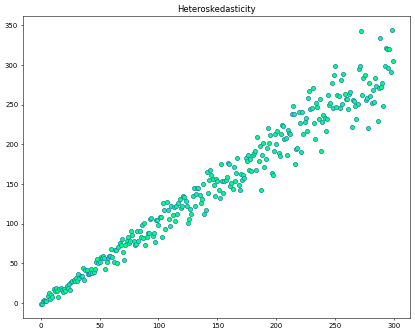

In [61]:
def generate_heteroskadastic_data(size, bounds = (0, 1000)):
    X = np.arange(bounds[0], size)
    sd_deviation = np.random.uniform(0, 4, size=size) + (X / 13)
    error = np.random.normal(0, sd_deviation, size=size)
    y_train = error + X
    plt.plot(y_train, "o", markerfacecolor='springgreen')
    plt.title("Heteroskedasticity")
    plt.show()
    
generate_heteroskadastic_data(300)  

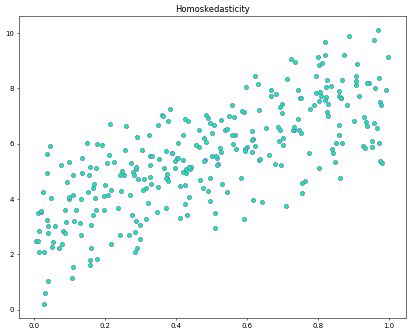

In [62]:
def generate_homoskedastic_data(size):
    X = []
    Y = []
    for i in range(size):
        x = random()
        c = random() + 1*random()
        y = 5*x + 3*c
        X.append(x)
        Y.append(y)

    data = pd.DataFrame(columns = ['X','Y'])
    data.X = X
    data.Y = Y
    plt.scatter(data.X, data.Y, c = "springgreen", edgecolor = 'mediumslateblue')
    plt.title("Homoskedasticity")
    plt.show()
    
generate_homoskedastic_data(300)

#### Fit a linear model on heteroskedastic data

In [63]:
N1 = 300
beta_0 = 8
beta_1 = 10
#
x = np.linspace(start = 0, stop = 5, num = N1)
e = np.random.normal(loc = 0, scale = 0.8, size = N1)
u = np.array(list(range(1, N1 + 1))) * e

y = beta_0 + beta_1 * x + u

In [64]:
# Initialize and fit the model and print the summary
linear_reg = sm.OLS(y, sm.add_constant(x)).fit()
print(linear_reg.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.7136     16.042      0.418      0.676     -24.857      38.284
x1            13.4241      5.553      2.418      0.016       2.497      24.351


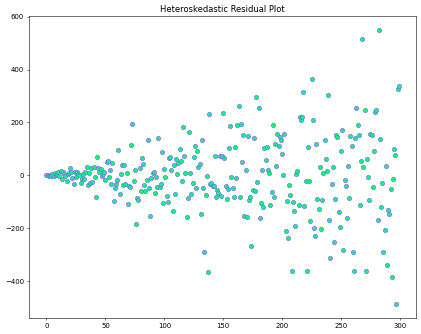

In [65]:
plot_opts = dict(linestyle = "None", marker = "o", color = "mediumslateblue", markerfacecolor = "springgreen")
_ = plt.plot(linear_reg.resid, **plot_opts)
_ = plt.title("Heteroskedastic Residual Plot")
plt.show()

#### Goldfeld–Quandt Test

In [66]:
# Goldfeld–Quandt Test
GQ_test = sm_diagnostic.het_goldfeldquandt(y = y, x = sm.add_constant(x), alternative = "two-sided")
print(pd.DataFrame(lzip(['F statistic', 'p-value'], GQ_test)))

# Since the p-value is less than 0.05, we conclude that the residuals are heteroskedastic

             0             1
0  F statistic  5.751878e+00
1      p-value  9.755465e-24


In [67]:
# Another way to do the above using the linear model we fit
GQ_test1 = sm_diagnostic.het_goldfeldquandt(y = linear_reg.model.endog, x = linear_reg.model.exog, alternative = "two-sided", idx = 1)
print(pd.DataFrame(lzip(['F statistic', 'p-value'], GQ_test1)))

             0             1
0  F statistic  5.751878e+00
1      p-value  9.755465e-24


#### Breusch–Pagan Test

In [68]:
BP_test = sm_diagnostic.het_breuschpagan(resid = linear_reg.resid, exog_het = linear_reg.model.exog)
print(pd.DataFrame(lzip(['LM statistic', 'p-value',  'F-value', 'F: p-value'], BP_test)))

# Since the p-value corresponding to the Lagrange multiplier statistic is less than 0.05
# we conclude that the residuals are heteroskedastic

              0             1
0  LM statistic  5.556695e+01
1       p-value  9.032976e-14
2       F-value  6.774432e+01
3    F: p-value  5.878027e-15


#### White's test

In [69]:
White_test = sm_diagnostic.het_white(resid = linear_reg.resid, exog = sm.add_constant(x))
print(pd.DataFrame(lzip(['LM statistic', 'p-value',  'F-value', 'F: p-value'], White_test)))
# Since the p-value is less than 0.05 we conclude that the residuals are heteroskadastic

              0             1
0  LM statistic  6.090591e+01
1       p-value  5.949075e-14
2       F-value  3.782832e+01
3    F: p-value  2.317215e-15


### How to fix it

#### White's correction

In [70]:
linear_reg_corrected = linear_reg.get_robustcov_results(cov_type='HC1', use_t=None)
White_test = sm_diagnostic.het_white(resid = linear_reg_corrected.resid, exog = sm.add_constant(x))
print(pd.DataFrame(lzip(['LM statistic', 'p-value',  'F-value', 'F: p-value'], White_test)))

              0             1
0  LM statistic  6.090591e+01
1       p-value  5.949075e-14
2       F-value  3.782832e+01
3    F: p-value  2.317215e-15
